In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("OK")

Matplotlib is building the font cache; this may take a moment.


OK


Definición del problema

Analizar los factores que influyen en el desempeño de los empleados, con el fin de identificar variables relevantes que impacten en la productividad organizacional.

Definición del problema

Analizar los factores que influyen en el desempeño de los empleados, con el fin de identificar variables relevantes que impacten en la productividad organizacional.

Objetivo general

Analizar el desempeño de los empleados a partir de variables demográficas, laborales y de comportamiento.

Objetivos específicos

- Evaluar la relación entre desempeño y horas extra
- Analizar la influencia del nivel educativo en el salario
- Identificar patrones en el equilibrio vida-trabajo

1. Carga de datos

Se carga el dataset desde la carpeta `data/raw` para iniciar la revisión de su estructura y contenido.

In [3]:
file_path = "../data/raw/10-employee_performance.csv"
df = pd.read_csv(file_path)

df.head()

,employee_id,age,gender,education,department,job_level,years_at_company,years_in_current_role,monthly_salary,overtime_hours_monthly,num_projects_completed,performance_rating,training_hours_yearly,work_life_balance_score,distance_from_home_km,num_companies_worked,job_satisfaction,relationship_with_manager,stock_option_level,attrition
0,1,38,Female,Master,IT,3,6.3,0.2,6072.54,11,7,2,39.0,5,4.4,3,3,5,3,0
1,2,32,Male,Bachelor,Finance,1,3.4,3.8,3058.51,15,6,3,57.1,4,4.5,2,4,4,2,0
2,3,24,Female,Bachelor,Engineering,1,0.8,2.9,9270.48,5,6,5,41.1,1,49.6,2,3,1,0,1
3,4,33,Male,Bachelor,Sales,5,0.2,1.6,7567.36,3,8,3,21.2,2,0.7,2,5,4,1,0
4,5,51,Male,Bachelor,Finance,3,3.8,7.1,5621.87,5,8,4,42.6,4,6.6,3,3,4,2,1


In [4]:
df.shape

(14000, 20)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   employee_id                14000 non-null  int64  
 1   age                        14000 non-null  int64  
 2   gender                     14000 non-null  str    
 3   education                  14000 non-null  str    
 4   department                 14000 non-null  str    
 5   job_level                  14000 non-null  int64  
 6   years_at_company           14000 non-null  float64
 7   years_in_current_role      14000 non-null  float64
 8   monthly_salary             14000 non-null  float64
 9   overtime_hours_monthly     14000 non-null  int64  
 10  num_projects_completed     14000 non-null  int64  
 11  performance_rating         14000 non-null  int64  
 12  training_hours_yearly      14000 non-null  float64
 13  work_life_balance_score    14000 non-null  int64  
 14  d

In [6]:
df.columns.tolist()

['employee_id',
 'age',
 'gender',
 'education',
 'department',
 'job_level',
 'years_at_company',
 'years_in_current_role',
 'monthly_salary',
 'overtime_hours_monthly',
 'num_projects_completed',
 'performance_rating',
 'training_hours_yearly',
 'work_life_balance_score',
 'distance_from_home_km',
 'num_companies_worked',
 'job_satisfaction',
 'relationship_with_manager',
 'stock_option_level',
 'attrition']

In [7]:
df.shape

(14000, 20)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   employee_id                14000 non-null  int64  
 1   age                        14000 non-null  int64  
 2   gender                     14000 non-null  str    
 3   education                  14000 non-null  str    
 4   department                 14000 non-null  str    
 5   job_level                  14000 non-null  int64  
 6   years_at_company           14000 non-null  float64
 7   years_in_current_role      14000 non-null  float64
 8   monthly_salary             14000 non-null  float64
 9   overtime_hours_monthly     14000 non-null  int64  
 10  num_projects_completed     14000 non-null  int64  
 11  performance_rating         14000 non-null  int64  
 12  training_hours_yearly      14000 non-null  float64
 13  work_life_balance_score    14000 non-null  int64  
 14  d

In [9]:
df.describe()

,employee_id,age,job_level,years_at_company,years_in_current_role,monthly_salary,overtime_hours_monthly,num_projects_completed,performance_rating,training_hours_yearly,work_life_balance_score,distance_from_home_km,num_companies_worked,job_satisfaction,relationship_with_manager,stock_option_level,attrition
count,14000.000000,14000.000000,14000.00000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.00000,14000.000000,14000.000000,14000.000000,14000.000000
mean,7000.500000,41.488071,2.38900,4.487936,2.498529,5310.341682,7.993071,5.991143,3.233571,39.787200,3.220500,14.840436,2.51450,3.380714,3.425500,1.019071,0.154286
std,4041.596219,11.501790,1.25103,4.445091,2.501401,2201.749606,2.827926,2.461866,0.983259,14.931219,1.094451,15.000216,1.59171,1.118483,1.041681,0.999246,0.361235
min,1.000000,22.000000,1.00000,0.000000,0.000000,1195.340000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.00000,1.000000,1.000000,0.000000,0.000000
25%,3500.750000,32.000000,1.00000,1.300000,0.700000,3768.370000,6.000000,4.000000,3.000000,29.700000,3.000000,4.200000,1.00000,3.000000,3.000000,0.000000,0.000000
50%,7000.500000,42.000000,2.00000,3.100000,1.700000,4916.160000,8.000000,6.000000,3.000000,39.600000,3.000000,10.300000,2.00000,4.000000,3.000000,1.000000,0.000000
75%,10500.250000,51.000000,3.00000,6.200000,3.500000,6416.060000,10.000000,8.000000,4.000000,50.000000,4.000000,20.300000,3.00000,4.000000,4.000000,2.000000,0.000000
max,14000.000000,61.000000,5.00000,44.400000,26.700000,28310.880000,21.000000,17.000000,5.000000,100.500000,5.000000,132.700000,11.00000,5.000000,5.000000,3.000000,1.000000


In [10]:
df.isnull().sum()

employee_id                  0
age                          0
gender                       0
education                    0
department                   0
job_level                    0
years_at_company             0
years_in_current_role        0
monthly_salary               0
overtime_hours_monthly       0
num_projects_completed       0
performance_rating           0
training_hours_yearly        0
work_life_balance_score      0
distance_from_home_km        0
num_companies_worked         0
job_satisfaction             0
relationship_with_manager    0
stock_option_level           0
attrition                    0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

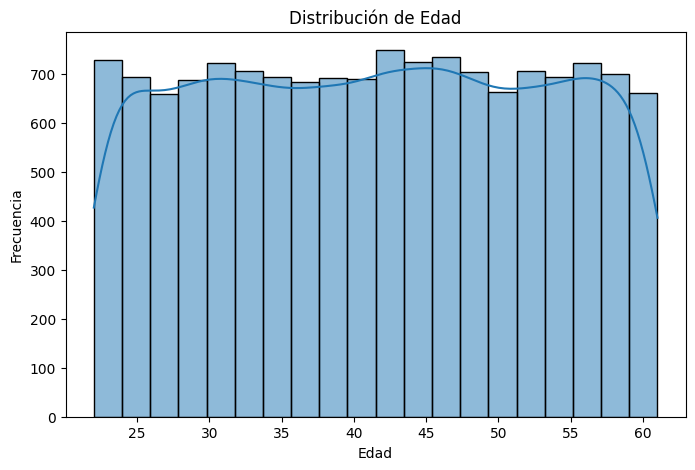

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

La distribución de edad es relativamente homogénea, sin concentraciones extremadamente marcadas en un solo rango etario. Esto sugiere que la muestra incluye empleados de diferentes edades y no presenta un sesgo fuerte hacia un grupo específico.

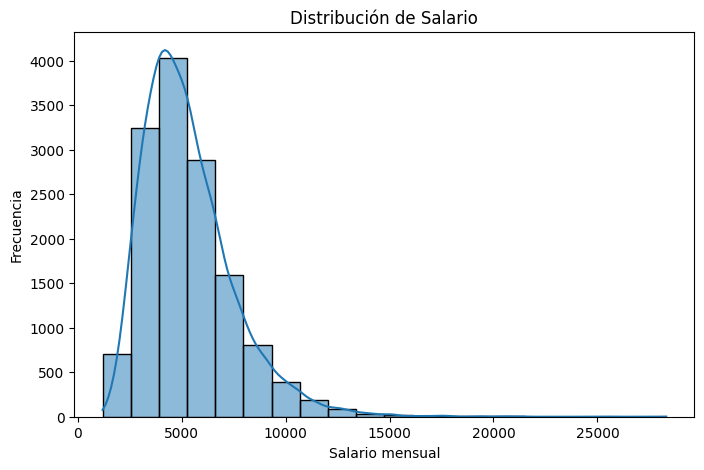

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['monthly_salary'], bins=20, kde=True)
plt.title('Distribución de Salario')
plt.xlabel('Salario mensual')
plt.ylabel('Frecuencia')
plt.show()

La distribución presenta una ligera asimetría positiva, evidenciando la existencia de empleados con salarios significativamente superiores al promedio.

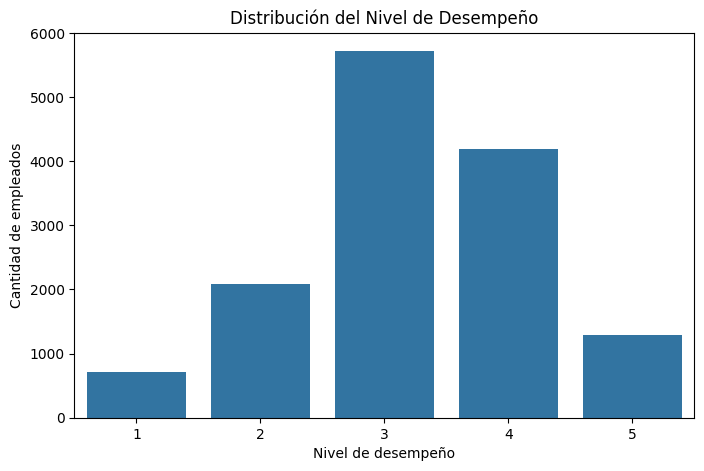

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x='performance_rating', data=df)
plt.title('Distribución del Nivel de Desempeño')
plt.xlabel('Nivel de desempeño')
plt.ylabel('Cantidad de empleados')
plt.show()

Este gráfico permite observar cómo se distribuyen los empleados según su desempeño. Si la mayor parte se concentra en categorías medias, ello sugeriría una distribución equilibrada sin predominio extremo de desempeños muy bajos o muy altos.

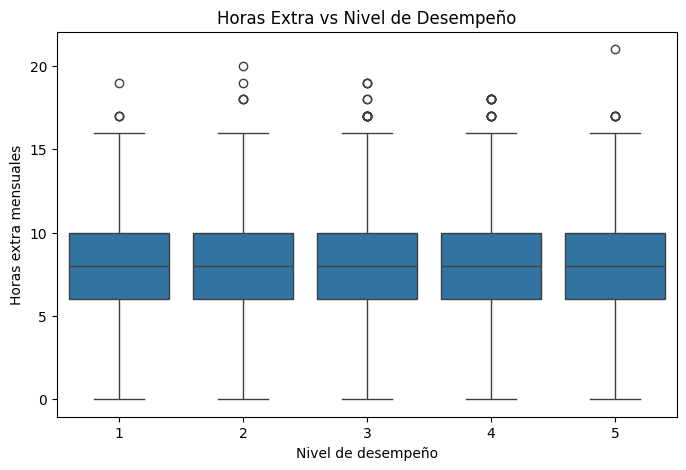

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x='performance_rating', y='overtime_hours_monthly', data=df)
plt.title('Horas Extra vs Nivel de Desempeño')
plt.xlabel('Nivel de desempeño')
plt.ylabel('Horas extra mensuales')
plt.show()

Este análisis permite evaluar si existe alguna relación entre la cantidad de horas extra y el desempeño. Si las medianas y distribuciones son similares entre categorías, se podría inferir que trabajar más horas no necesariamente implica un mejor rendimiento.

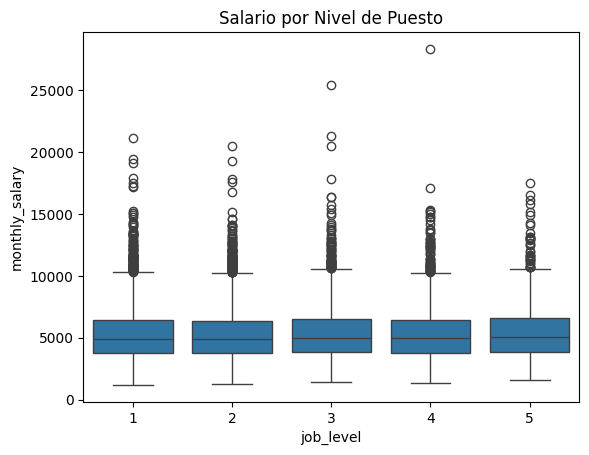

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='job_level', y='monthly_salary', data=df)
plt.title('Salario por Nivel de Puesto')
plt.xlabel('Nivel de puesto')
plt.ylabel('Salario mensual')
plt.show()

Este gráfico permite identificar si el salario aumenta conforme se incrementa el nivel del puesto. Una tendencia ascendente entre categorías reforzaría la consistencia interna del dataset y la coherencia entre jerarquía organizacional y remuneración.

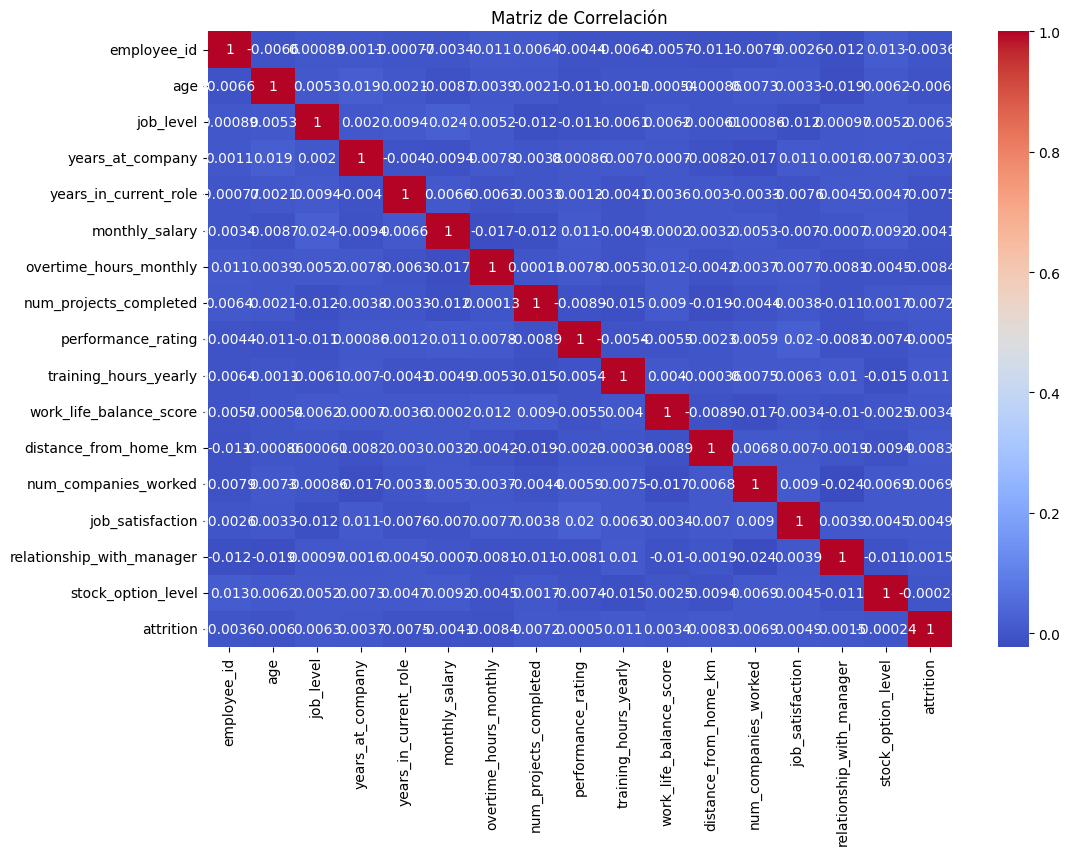

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

La matriz de correlación permite identificar relaciones lineales entre variables numéricas. Los coeficientes cercanos a 1 o -1 indican asociaciones más fuertes, mientras que los valores cercanos a 0 reflejan relaciones débiles o inexistentes.

In [18]:
df.select_dtypes(include='object').columns

C:\Users\luisi\AppData\Local\Temp\ipykernel_45808\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['gender', 'education', 'department'], dtype='str')

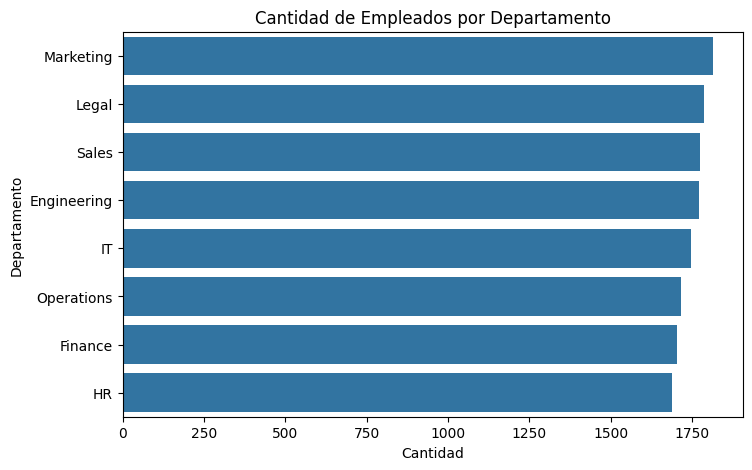

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(y='department', data=df, order=df['department'].value_counts().index)
plt.title('Cantidad de Empleados por Departamento')
plt.xlabel('Cantidad')
plt.ylabel('Departamento')
plt.show()

Este gráfico permite observar cómo se distribuyen los empleados entre departamentos. Una mayor concentración en determinadas áreas podría reflejar el peso operativo de ciertas funciones dentro de la organización.

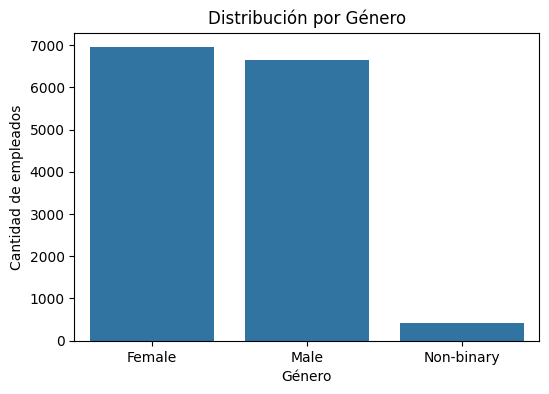

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title('Distribución por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de empleados')
plt.show()

La distribución por género permite identificar si la muestra se encuentra equilibrada o si existe predominio de una categoría. Esto resulta relevante para interpretar posteriormente posibles diferencias en otras variables.

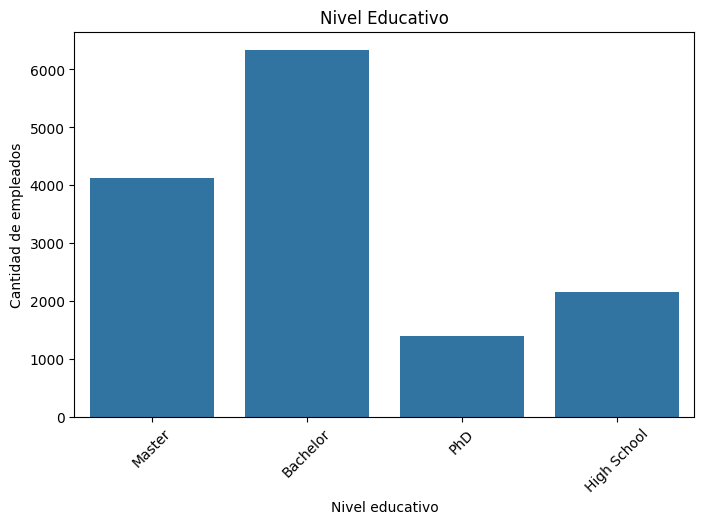

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(x='education', data=df)
plt.title('Nivel Educativo')
plt.xlabel('Nivel educativo')
plt.ylabel('Cantidad de empleados')
plt.xticks(rotation=45)
plt.show()

Este gráfico muestra la composición de la muestra según nivel educativo. Permite identificar qué perfiles académicos predominan y si existe diversidad formativa en la organización.

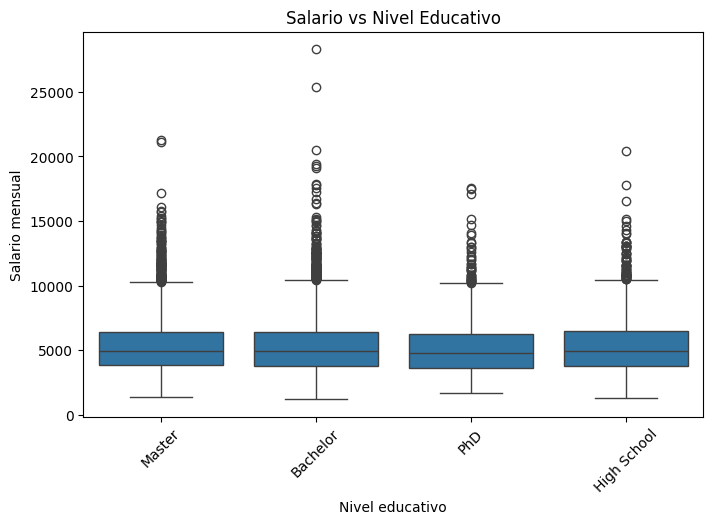

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x='education', y='monthly_salary', data=df)
plt.title('Salario vs Nivel Educativo')
plt.xlabel('Nivel educativo')
plt.ylabel('Salario mensual')
plt.xticks(rotation=45)
plt.show()

Este análisis permite evaluar si el nivel educativo parece estar asociado con diferencias salariales. Si los valores centrales aumentan en categorías educativas superiores, ello sugeriría una posible relación positiva entre formación y remuneración.

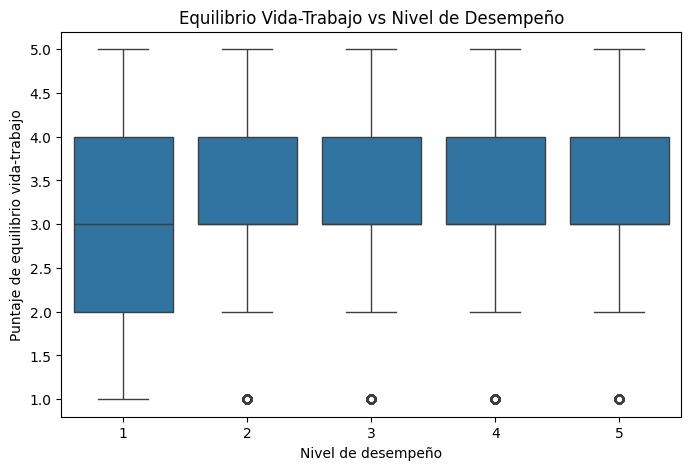

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(x='performance_rating', y='work_life_balance_score', data=df)
plt.title('Equilibrio Vida-Trabajo vs Nivel de Desempeño')
plt.xlabel('Nivel de desempeño')
plt.ylabel('Puntaje de equilibrio vida-trabajo')
plt.show()

Este gráfico permite analizar si existe alguna asociación entre el equilibrio vida-trabajo y el desempeño. Diferencias visibles en medianas o dispersión podrían sugerir que esta variable influye en la productividad o satisfacción laboral.

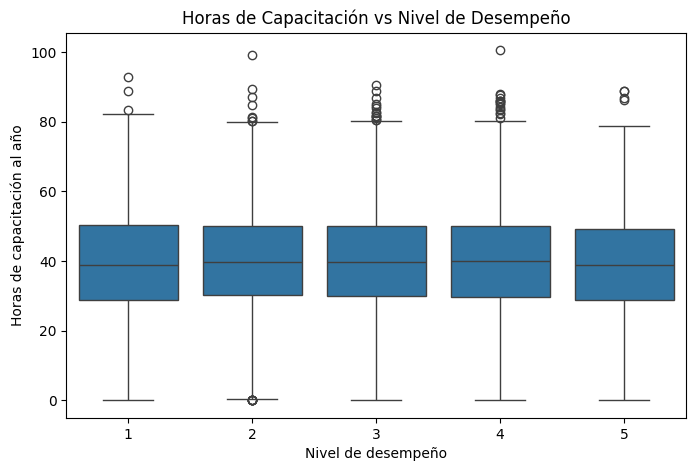

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x='performance_rating', y='training_hours_yearly', data=df)
plt.title('Horas de Capacitación vs Nivel de Desempeño')
plt.xlabel('Nivel de desempeño')
plt.ylabel('Horas de capacitación al año')
plt.show()

Este análisis busca identificar si los empleados con mayor desempeño reciben o acumulan más horas de capacitación. Si se observan diferencias claras entre categorías, podría inferirse una relación entre formación y rendimiento.

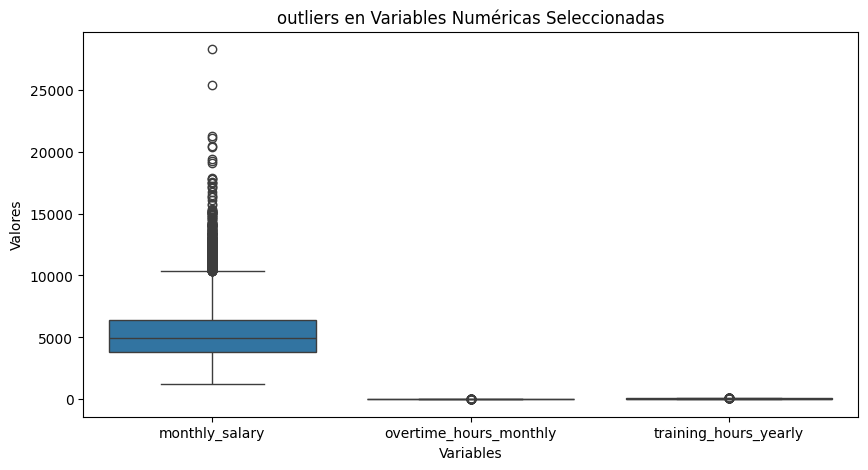

In [40]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['monthly_salary','overtime_hours_monthly','training_hours_yearly']])
plt.title('outliers en Variables Numéricas Seleccionadas')
plt.xlabel('Variables')
plt.ylabel('Valores')
plt.show()

Este gráfico permite detectar outliers en variables numéricas relevantes. La presencia de valores extremos no necesariamente implica errores, pero sí indica observaciones que deben revisarse por su posible impacto en análisis posteriores.

Conclusiones Generales

- El dataset presenta una estructura adecuada para realizar análisis exploratorio de variables demográficas, laborales y de desempeño.
- La distribución de edad muestra una muestra relativamente heterogénea, sin una concentración extrema en un solo rango etario.
- Las variables salariales y de horas extra permiten explorar diferencias internas entre empleados y niveles de puesto.
- El nivel de desempeño constituye una variable central para analizar relaciones con capacitación, equilibrio vida-trabajo y horas extra.
- Las variables categóricas como departamento, género y nivel educativo aportan contexto importante para segmentar a los empleados.
- La detección de outliers y la matriz de correlación ayudan a identificar patrones relevantes y posibles valores extremos que deberán considerarse en etapas posteriores del proyecto.

Insights clave

- El desempeño no presenta una relación directa con las horas extra trabajadas.
- El salario aumenta conforme el nivel de puesto, mostrando coherencia organizacional.
- No se observa una correlación fuerte entre variables numéricas, lo que sugiere independencia entre factores analizados.